aqui realizaremos la importacion de las librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv("/content/padron_comuna_sexo_edad.csv") #creamos un dataframe llamado df y cargamos el dataset csv

In [ ]:
df.head() #visualizamos las primeras 5 filas

,Región,Comuna,Electores en padrón definitivo oct 2024,Cantidad de Mujeres,Cantidad de Hombres,Edad 18-19,Edad 20-29,Edad 30-39,Edad 40-49,Edad 50-59,Edad 60-69,Edad 70-79,Edad 80-89,90 o más
0,DE ARICA Y PARINACOTA,ARICA,185.158,93.160,91.998,6.267,31.849,36.194,32.729,31.278,23.814,15.143,6.584,1.3
1,DE ARICA Y PARINACOTA,CAMARONES,2.746,1.380,1.366,59.000,367,567,511,527,372,236,86.000,21.0
2,DE ARICA Y PARINACOTA,GENERAL LAGOS,1.526,635,891,19.000,152,280,341,323,184,152,63.000,12.0
3,DE ARICA Y PARINACOTA,PUTRE,4.831,1.991,2.840,98.000,647,914,1.084,964,560,368,162.000,34.0
4,DE TARAPACA,ALTO HOSPICIO,68.737,34.960,33.777,3.634,16.430,15.825,12.025,10.209,6.957,2.815,728.000,114.0


In [ ]:
df.tail()  #visualizamos las ultimas 5 filas

,Región,Comuna,Electores en padrón definitivo oct 2024,Cantidad de Mujeres,Cantidad de Hombres,Edad 18-19,Edad 20-29,Edad 30-39,Edad 40-49,Edad 50-59,Edad 60-69,Edad 70-79,Edad 80-89,90 o más
342,DE MAGALLANES Y DE LA ANTARTICA CHILENA,RIO VERDE,718,246,472,9.000,54,116,161,173,129,54,21.000,1.000
343,DE MAGALLANES Y DE LA ANTARTICA CHILENA,SAN GREGORIO,587,225,362,8.000,81,123,122,98,98,35,19.000,3.000
344,DE MAGALLANES Y DE LA ANTARTICA CHILENA,TIMAUKEL,902,321,581,12.000,114,179,208,191,138,46,13.000,1.000
345,DE MAGALLANES Y DE LA ANTARTICA CHILENA,TORRES DEL PAINE,1.309,492,817,10.000,122,281,371,261,164,74,23.000,3.000
346,TOTAL,NaN,15.450.377,7.908.994,7.541.383,469.737,2.566.643,3.036.481,2.631.652,2.590.742,2.165.771,1.282.327,586.281,120.743


In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(347, 14)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
Región,object
Comuna,object
Electores en padrón definitivo oct 2024,object
Cantidad de Mujeres,object
Cantidad de Hombres,object
Edad 18-19,float64
Edad 20-29,object
Edad 30-39,object
Edad 40-49,object
Edad 50-59,object


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Región,0
Comuna,1
Electores en padrón definitivo oct 2024,0
Cantidad de Mujeres,0
Cantidad de Hombres,0
Edad 18-19,0
Edad 20-29,0
Edad 30-39,0
Edad 40-49,0
Edad 50-59,0


Solamente observamos 1 nulo presente en la tabla comuna, borraremos el registro nulo ya que solamente es 1

In [ ]:
df = df.dropna() #aplicamos la tecnica mas agresiva de eliminacion de la fila con nulo

In [ ]:
df.isnull().sum() #confirmamos la eliminacion del nulo

,0
Región,0
Comuna,0
Electores en padrón definitivo oct 2024,0
Cantidad de Mujeres,0
Cantidad de Hombres,0
Edad 18-19,0
Edad 20-29,0
Edad 30-39,0
Edad 40-49,0
Edad 50-59,0


In [ ]:
df.columns #mostramos los nombres de las columnas

Index([' Región', 'Comuna', 'Electores en padrón definitivo oct 2024',
       'Cantidad de Mujeres', ' Cantidad de Hombres', 'Edad 18-19',
       'Edad 20-29', 'Edad 30-39', 'Edad 40-49', 'Edad 50-59', 'Edad 60-69',
       'Edad 70-79', 'Edad 80-89', '90 o más'],
      dtype='object')


# Realizaremos un mapeo de datos
* Region: Categorico Nominal
* Comuna: Categorico Nominal
* Electores en padron definitivo oct 2024: Numerico Discreto
* Cantidad de Mujeres: Numerico Discreto
* Cantidad de Hombres: Numerico Discreto
* Edad 18-19: Numerico Discreto
* Edad 20-29: Numerico Discreto
* Edad 30-39: Numerico Discreto
* Edad 40-49: Numerico Discreto
* Edad 50-59: Numerico Discreto
* Edad 60-69: Numerico Discreto
* Edad 70-79: Numerico Discreto
* Edad 80-89: Numerico Discreto
* 90 o mas: Numerico Discreto


### Clasificacion de Variables

* **Categorico Nominal:** Categorias sin un orden o jerarquia especifica.
  * *Ejemplo:* Region, Comuna, Genero.
* **Categorico Ordinal:** Categorias que siguen un orden logico o escala.
  * *Ejemplo:* Nivel educacional (Basica, Media, Superior).
* **Numerico Discreto:** Valores que surgen de un conteo y no admiten decimales.
  * *Ejemplo:* Cantidad de personas, Numero de hijos.
* **Numerico Continuo:** Valores que resultan de una medicion y pueden tener decimales infinitos.
  * *Ejemplo:* Estatura, Peso, Temperatura.


In [ ]:
cant_cat_col_region_df = df[' Región'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de region
print(cant_cat_col_region_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad regiones: {cant_cat_col_region_df.count()}")

 Región
METROPOLITANA DE SANTIAGO                       52
DE VALPARAISO                                   38
DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS       33
DEL BIOBIO                                      33
DE LA ARAUCANIA                                 32
DEL MAULE                                       30
DE LOS LAGOS                                    30
DE ÑUBLE                                        21
DE COQUIMBO                                     15
DE LOS RIOS                                     12
DE MAGALLANES Y DE LA ANTARTICA CHILENA         11
DE AYSEN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO    10
DE ATACAMA                                       9
DE ANTOFAGASTA                                   9
DE TARAPACA                                      7
DE ARICA Y PARINACOTA                            4
Name: count, dtype: int64
cantidad regiones: 16


tenemos 17 categorias de regiones distintas

In [ ]:
cant_cat_col_comuna_df = df['Comuna'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Comuna
print(cant_cat_col_comuna_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad Comuna: {cant_cat_col_comuna_df.count()}")

Comuna
TORRES DEL PAINE               1
ARICA                          1
CAMARONES                      1
GENERAL LAGOS                  1
PUTRE                          1
ALTO HOSPICIO                  1
CAMIÑA                         1
COLCHANE                       1
HUARA                          1
IQUIQUE                        1
COYHAIQUE                      1
COCHRANE                       1
CISNES                         1
CHILE CHICO                    1
AYSEN                          1
SAN PABLO                      1
SAN JUAN DE LA COSTA           1
RIO NEGRO                      1
QUINCHAO                       1
QUEMCHI                        1
QUELLON                        1
QUEILEN                        1
PUYEHUE                        1
PURRANQUE                      1
PUQUELDON                      1
PUERTO VARAS                   1
RIO HURTADO                    1
PUNITAQUI                      1
PAIGUANO                       1
OVALLE                         1
MON

tenemos 346 comunas o categorias distintas

# Estadistica descriptiva a las variables numericas

In [ ]:
df.describe()

,Edad 18-19,Edad 80-89,90 o más
count,346.000000,346.000000,346.000000
mean,267.383237,297.698731,172.324220
std,277.314067,311.987651,196.783128
min,1.000000,0.000000,0.000000
25%,4.757000,3.662250,53.500000
50%,196.500000,242.500000,112.000000
75%,430.750000,546.750000,212.750000
max,993.000000,992.000000,995.000000


solamente nos identificó 3 columnas como numericas, teniamos mas, realizaremos la conversión del resto de las variables numericas

In [ ]:
#utilizaremos expresiones regulares para eliminar los puntos
cols_a_convertir = [
    'Electores en padron definitivo oct 2024', 'Cantidad de Mujeres',
    'Cantidad de Hombres', 'Edad 18-19', 'Edad 20-29', 'Edad 30-39',
    'Edad 40-49', 'Edad 50-59', 'Edad 60-69', 'Edad 70-79',
    'Edad 80-89', '90 o mas'
]

for col in cols_a_convertir:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('.', '', regex=False), errors='coerce')


In [ ]:
df.describe() # aplicamos ahora la estadistica descriptiva con todas las variables numericas identificadas y convertidas

,Cantidad de Mujeres,Edad 18-19,Edad 20-29,Edad 30-39,Edad 40-49,Edad 50-59,Edad 60-69,Edad 70-79,Edad 80-89,90 o más
count,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000
mean,22858.364162,3627.338150,7418.043353,8775.956647,7605.930636,7487.693642,6259.453757,3706.147399,4285.413295,172.324220
std,33983.781469,2612.011582,11462.202334,13776.804295,11489.465711,10503.739772,8950.709794,5231.677579,2892.868138,196.783128
min,21.000000,10.000000,9.000000,50.000000,50.000000,30.000000,17.000000,7.000000,0.000000,0.000000
25%,4649.500000,1599.750000,1374.250000,1686.500000,1504.500000,1731.250000,1439.250000,888.000000,1870.500000,53.500000
50%,9114.500000,3120.000000,2766.500000,3188.500000,2899.000000,3200.000000,2800.500000,1680.500000,3782.500000,112.000000
75%,23259.750000,5010.000000,7482.250000,8487.500000,7595.000000,7792.750000,6656.250000,3890.750000,6290.000000,212.750000
max,219229.000000,15414.000000,84086.000000,102224.000000,77986.000000,65926.000000,59723.000000,30707.000000,14998.000000,995.000000


# Importaremos las librerias para realizar el encoder a region y comuna

In [ ]:
pip install category_encoders

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
#
ohe = OneHotEncoder(sparse_output=False)
region_encoded = ohe.fit_transform(df[[' Región']])

# Convertimos el resultado en un DataFrame con nombres de columnas claros
region_df = pd.DataFrame(
    region_encoded,
    columns=ohe.get_feature_names_out([' Región']),
    index=df.index
)

In [ ]:
# 3. Binary Encoding para 'Comuna' usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como las comunas
be = ce.BinaryEncoder(cols=['Comuna'])
df_binary = be.fit_transform(df['Comuna'])

# 4. Concatenar todo y eliminar las columnas originales
# Unimos el dataframe original (sin Region y Comuna) con las nuevas columnas
df_final = pd.concat([df.drop(columns=[' Región', 'Comuna']), region_df, df_binary], axis=1)

# 5. Ver los cambios
print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")

  Electores en padrón definitivo oct 2024  Cantidad de Mujeres  \
0                                 185.158                93160   
1                                   2.746                 1380   
2                                   1.526                  635   
3                                   4.831                 1991   
4                                  68.737                34960   

   Cantidad de Hombres  Edad 18-19  Edad 20-29  Edad 30-39  Edad 40-49  \
0               91.998        6267       31849       36194       32729   
1                1.366         590         367         567         511   
2                  891         190         152         280         341   
3                2.840         980         647         914        1084   
4               33.777        3634       16430       15825       12025   

   Edad 50-59  Edad 60-69  Edad 70-79  Edad 80-89  90 o más  \
0       31278       23814       15143        6584       1.3   
1         527         372       

In [ ]:
df_final.head(100) #observamos el nuevo dataframe con las variables y encoder aplicado

,Electores en padrón definitivo oct 2024,Cantidad de Mujeres,Cantidad de Hombres,Edad 18-19,Edad 20-29,Edad 30-39,Edad 40-49,Edad 50-59,Edad 60-69,Edad 70-79,Edad 80-89,90 o más,Región_DE ANTOFAGASTA,Región_DE ARICA Y PARINACOTA,Región_DE ATACAMA,Región_DE AYSEN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO,Región_DE COQUIMBO,Región_DE LA ARAUCANIA,Región_DE LOS LAGOS,Región_DE LOS RIOS,Región_DE MAGALLANES Y DE LA ANTARTICA CHILENA,Región_DE TARAPACA,Región_DE VALPARAISO,Región_DE ÑUBLE,Región_DEL BIOBIO,Región_DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,Región_DEL MAULE,Región_METROPOLITANA DE SANTIAGO,Comuna_0,Comuna_1,Comuna_2,Comuna_3,Comuna_4,Comuna_5,Comuna_6,Comuna_7,Comuna_8
0,185.158,93160,91.998,6267,31849,36194,32729,31278,23814,15143,6584,1.300,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1
1,2.746,1380,1.366,590,367,567,511,527,372,236,860,21.000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0
2,1.526,635,891,190,152,280,341,323,184,152,630,12.000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,1
3,4.831,1991,2.840,980,647,914,1084,964,560,368,1620,34.000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0
4,68.737,34960,33.777,3634,16430,15825,12025,10209,6957,2815,7280,114.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,1
5,2.979,1539,1.440,950,533,566,572,559,345,199,990,11.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,1,0
6,2.744,1299,1.445,950,588,619,560,428,224,146,680,16.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,1,1
7,4.140,1932,2.208,930,488,640,750,687,627,429,3710,55.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,0,0,0
8,165.299,81578,83.721,4886,25436,35961,32965,26327,21843,12314,4618,949.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,0,0,1
9,6.291,3158,3.133,1990,1012,1259,1114,947,878,579,2570,46.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,0,1,0


In [ ]:
df_final.describe()

,Cantidad de Mujeres,Edad 18-19,Edad 20-29,Edad 30-39,Edad 40-49,Edad 50-59,Edad 60-69,Edad 70-79,Edad 80-89,90 o más,Región_DE ANTOFAGASTA,Región_DE ARICA Y PARINACOTA,Región_DE ATACAMA,Región_DE AYSEN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO,Región_DE COQUIMBO,Región_DE LA ARAUCANIA,Región_DE LOS LAGOS,Región_DE LOS RIOS,Región_DE MAGALLANES Y DE LA ANTARTICA CHILENA,Región_DE TARAPACA,Región_DE VALPARAISO,Región_DE ÑUBLE,Región_DEL BIOBIO,Región_DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,Región_DEL MAULE,Región_METROPOLITANA DE SANTIAGO,Comuna_0,Comuna_1,Comuna_2,Comuna_3,Comuna_4,Comuna_5,Comuna_6,Comuna_7,Comuna_8
count,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000
mean,22858.364162,3627.338150,7418.043353,8775.956647,7605.930636,7487.693642,6259.453757,3706.147399,4285.413295,172.324220,0.026012,0.011561,0.026012,0.028902,0.043353,0.092486,0.086705,0.034682,0.031792,0.020231,0.109827,0.060694,0.095376,0.095376,0.086705,0.150289,0.263006,0.369942,0.447977,0.462428,0.494220,0.494220,0.497110,0.500000,0.500000
std,33983.781469,2612.011582,11462.202334,13776.804295,11489.465711,10503.739772,8950.709794,5231.677579,2892.868138,196.783128,0.159400,0.107052,0.159400,0.167773,0.203945,0.290130,0.281810,0.183238,0.175700,0.140994,0.313126,0.239113,0.294159,0.294159,0.281810,0.357872,0.440903,0.483488,0.498006,0.499308,0.500691,0.500691,0.500716,0.500724,0.500724
min,21.000000,10.000000,9.000000,50.000000,50.000000,30.000000,17.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4649.500000,1599.750000,1374.250000,1686.500000,1504.500000,1731.250000,1439.250000,888.000000,1870.500000,53.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9114.500000,3120.000000,2766.500000,3188.500000,2899.000000,3200.000000,2800.500000,1680.500000,3782.500000,112.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000
75%,23259.750000,5010.000000,7482.250000,8487.500000,7595.000000,7792.750000,6656.250000,3890.750000,6290.000000,212.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,219229.000000,15414.000000,84086.000000,102224.000000,77986.000000,65926.000000,59723.000000,30707.000000,14998.000000,995.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


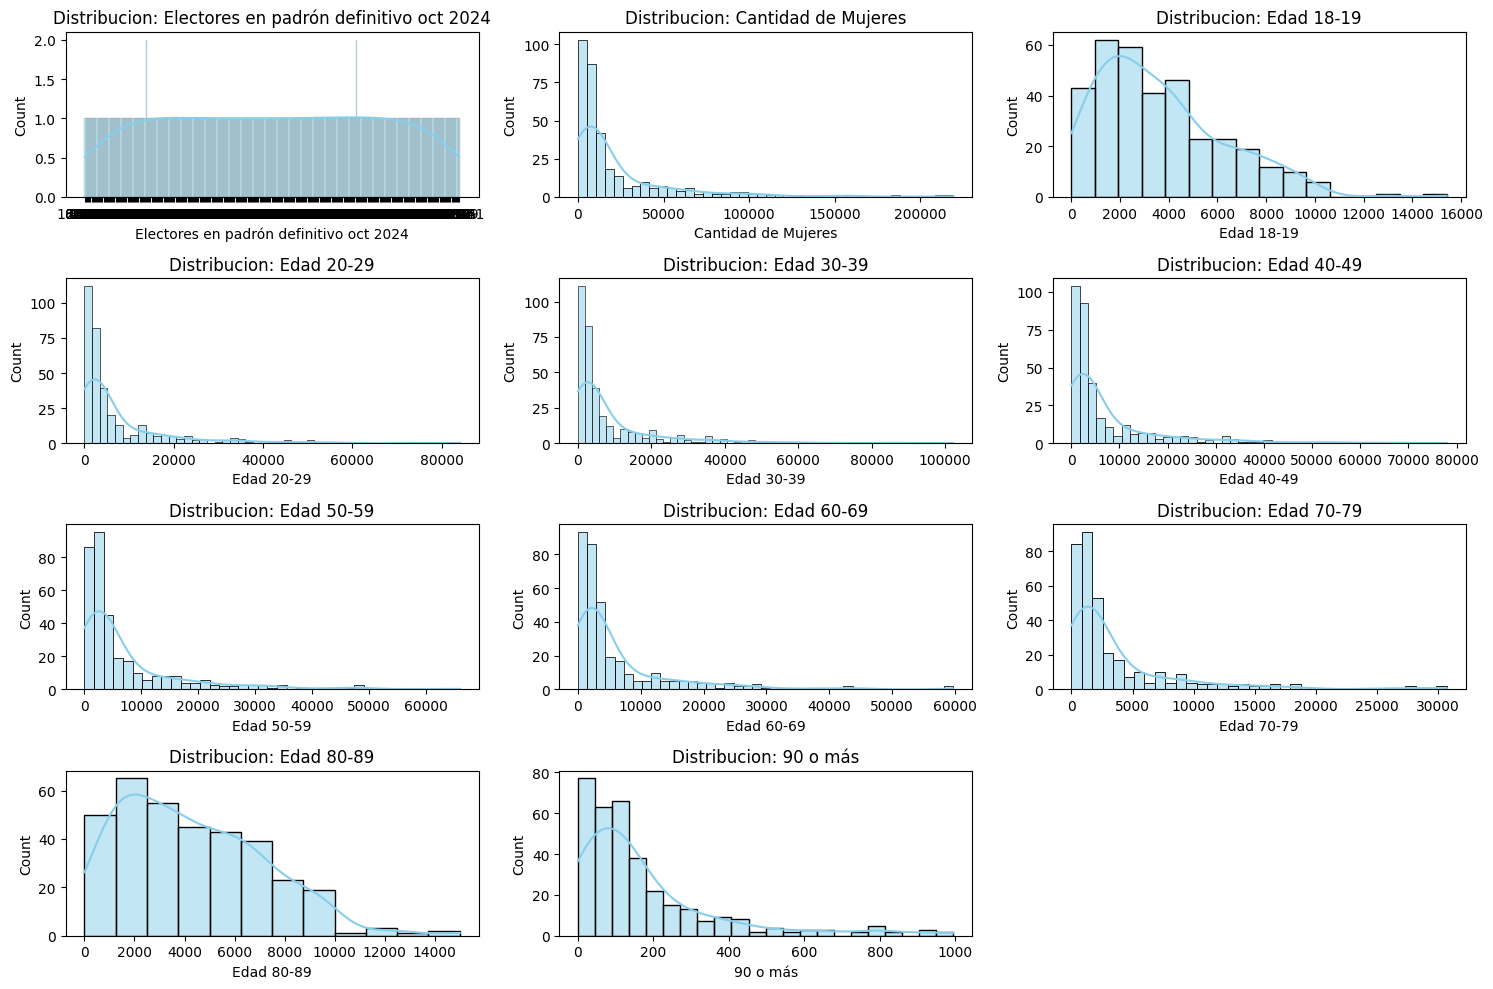

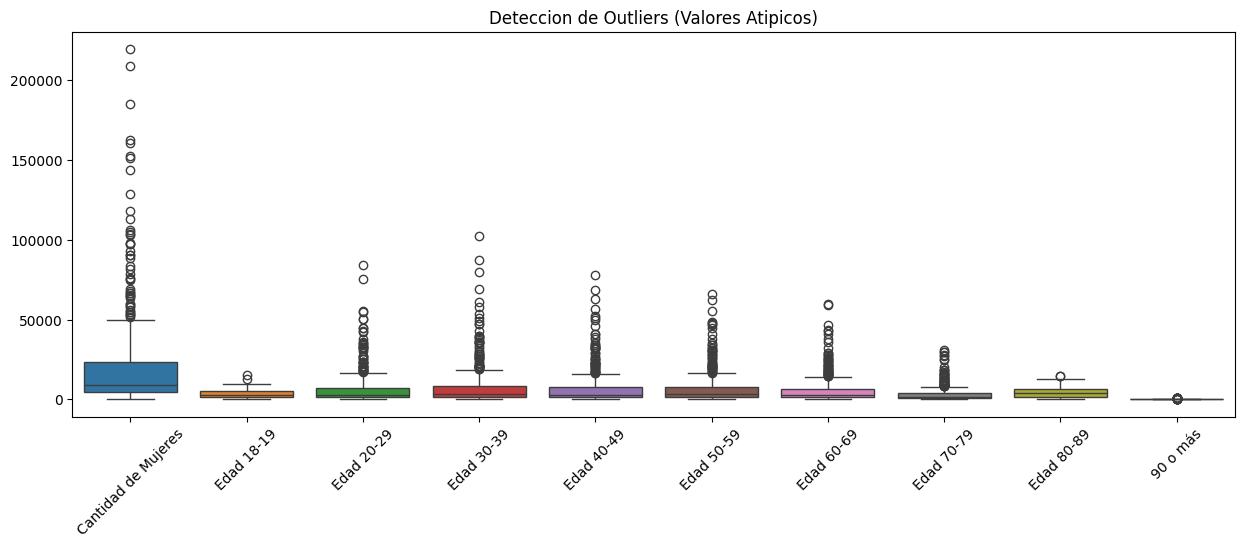

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas numericas originales (sin las codificadas)
cols_numericas = [
    'Electores en padrón definitivo oct 2024', 'Cantidad de Mujeres',
    'Edad 18-19', 'Edad 20-29', 'Edad 30-39', 'Edad 40-49',
    'Edad 50-59', 'Edad 60-69', 'Edad 70-79', 'Edad 80-89', '90 o más'
]

# Configuracion de graficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    # Histograma con curva de densidad
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()

# Boxplot para detectar Outliers
plt.figure(figsize=(15, 5))
sns.boxplot(data=df[cols_numericas])
plt.xticks(rotation=45)
plt.title('Deteccion de Outliers (Valores Atipicos)')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las columnas numericas que queremos estandarizar
# (Asegurate de que los nombres coincidan exactamente con tu df_final)
cols_a_escalar = [
    'Electores en padrón definitivo oct 2024', 'Cantidad de Mujeres',
    'Edad 18-19', 'Edad 20-29', 'Edad 30-39', 'Edad 40-49',
    'Edad 50-59', 'Edad 60-69', 'Edad 70-79', 'Edad 80-89', '90 o más'
]

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalamiento a df_final
# Usamos una copia para mantener la integridad de los datos originales si es necesario
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

# 4. Verificacion rapida
print("Primeras 5 filas con datos estandarizados:")
print(df_final_esc[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados:
   Electores en padrón definitivo oct 2024  Cantidad de Mujeres  Edad 18-19  \
0                                 1.007954             2.071678    1.012049   
1                                -0.471573            -0.632933   -1.164519   
2                                -0.481468            -0.654887   -1.317879   
3                                -0.454662            -0.614928   -1.014992   
4                                 0.063674             0.356616    0.002554   

   Edad 20-29  Edad 30-39  Edad 40-49  Edad 50-59  Edad 60-69  Edad 70-79  \
0    2.134523    1.993042    2.189784    2.268217    1.964087    2.189243   
1   -0.616047   -0.596716   -0.618410   -0.663647   -0.658716   -0.664256   
2   -0.634831   -0.617579   -0.633228   -0.683097   -0.679751   -0.680335   
3   -0.591583   -0.571493   -0.568466   -0.621982   -0.637682   -0.638988   
4    0.787371    0.512401    0.385176    0.259455    0.078045   -0.170584   

   Edad 80-89  90 o

In [ ]:
df_final_esc.corr()

,Electores en padrón definitivo oct 2024,Cantidad de Mujeres,Cantidad de Hombres,Edad 18-19,Edad 20-29,Edad 30-39,Edad 40-49,Edad 50-59,Edad 60-69,Edad 70-79,Edad 80-89,90 o más,Región_DE ANTOFAGASTA,Región_DE ARICA Y PARINACOTA,Región_DE ATACAMA,Región_DE AYSEN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO,Región_DE COQUIMBO,Región_DE LA ARAUCANIA,Región_DE LOS LAGOS,Región_DE LOS RIOS,Región_DE MAGALLANES Y DE LA ANTARTICA CHILENA,Región_DE TARAPACA,Región_DE VALPARAISO,Región_DE ÑUBLE,Región_DEL BIOBIO,Región_DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,Región_DEL MAULE,Región_METROPOLITANA DE SANTIAGO,Comuna_0,Comuna_1,Comuna_2,Comuna_3,Comuna_4,Comuna_5,Comuna_6,Comuna_7,Comuna_8
Electores en padrón definitivo oct 2024,1.000000,0.444516,0.463681,-0.012936,0.443061,0.445852,0.443944,0.438905,0.438016,0.430679,0.006303,-0.040001,-0.007844,-1.080796e-02,-0.044516,1.423967e-01,-0.028307,-8.344698e-02,-8.728150e-02,-4.665764e-02,0.357633,-0.027230,2.006761e-02,-0.081654,-0.051139,-0.094832,-7.402136e-02,1.866178e-01,0.073950,-1.636925e-01,0.202375,6.284253e-04,0.026818,0.030169,-1.264164e-02,-4.140067e-02,9.657617e-02
Cantidad de Mujeres,0.444516,1.000000,0.106206,0.304345,0.990888,0.989861,0.993055,0.997689,0.994204,0.984255,0.366213,0.133698,0.022052,4.567316e-03,-0.044635,-9.152625e-02,-0.000468,-7.690228e-02,-8.840194e-02,-4.048221e-02,-0.084554,-0.017998,-8.220261e-04,-0.089144,-0.014160,-0.097945,-6.253433e-02,4.548273e-01,-0.185194,-1.175309e-01,0.188859,1.547898e-01,-0.065779,-0.046264,2.582862e-02,-2.723052e-02,7.104103e-02
Cantidad de Hombres,0.463681,0.106206,1.000000,-0.185590,0.109144,0.113221,0.109409,0.099283,0.099583,0.094672,-0.190737,-0.136888,0.077788,1.610739e-01,-0.042496,2.605751e-01,-0.042581,-8.238320e-02,-8.214064e-02,-4.756075e-02,0.516036,-0.031755,-3.818809e-02,-0.072563,-0.068891,-0.087983,-7.645870e-02,2.423631e-02,0.185292,-1.809511e-01,0.172029,-1.294012e-01,0.041556,-0.003960,-6.970754e-02,-3.653211e-02,7.504349e-02
Edad 18-19,-0.012936,0.304345,-0.185590,1.000000,0.328968,0.304060,0.295390,0.302062,0.307102,0.280393,0.441524,-0.017347,-0.021080,-6.719594e-02,-0.014495,-1.392269e-01,0.093958,1.054095e-01,-8.116568e-02,4.516568e-02,-0.175972,-0.057781,7.382787e-02,-0.018889,0.027105,0.027403,-5.375493e-02,5.771395e-02,-0.102613,-3.150922e-04,-0.010572,1.008112e-01,-0.051193,0.002946,2.119344e-02,-7.419034e-02,-2.107044e-02
Edad 20-29,0.443061,0.990888,0.109144,0.328968,1.000000,0.979329,0.979069,0.990310,0.984296,0.960079,0.343272,0.136521,0.033080,7.896438e-03,-0.039359,-9.073976e-02,0.003089,-7.817562e-02,-8.617975e-02,-4.076894e-02,-0.085043,-0.009201,-8.932516e-03,-0.090909,-0.014173,-0.094793,-6.383603e-02,4.470972e-01,-0.184585,-1.241301e-01,0.185114,1.557330e-01,-0.058246,-0.033283,2.297281e-02,-4.977871e-02,6.071153e-02
Edad 30-39,0.445852,0.989861,0.113221,0.304060,0.979329,1.000000,0.996207,0.985961,0.975350,0.960939,0.359580,0.127120,0.043620,5.603516e-03,-0.037852,-8.523761e-02,-0.001895,-8.306294e-02,-8.505231e-02,-4.403732e-02,-0.079471,-0.005980,-1.428846e-02,-0.092228,-0.023978,-0.095495,-6.487601e-02,4.584459e-01,-0.183914,-1.146451e-01,0.169266,1.365655e-01,-0.066328,-0.038051,1.729083e-02,-2.720635e-02,7.382811e-02
Edad 40-49,0.443944,0.993055,0.109409,0.295390,0.979069,0.996207,1.000000,0.990429,0.978275,0.970101,0.362337,0.133534,0.038998,9.994989e-03,-0.042239,-8.621467e-02,-0.002937,-8.268771e-02,-8.423284e-02,-4.564878e-02,-0.076882,-0.005077,-9.893214e-03,-0.093454,-0.023944,-0.096753,-6.502523e-02,4.585412e-01,-0.182917,-1.195113e-01,0.174578,1.406681e-01,-0.065510,-0.042137,2.148507e-02,-2.217903e-02,7.184692e-02
Edad 50-59,0.438905,0.997689,0.099283,0.302062,0.990310,0.985961,0.990429,1.000000,0.992084,0.981620,0.357394,0.150138,0.022375,8.097307e-03,-0.045507,-9.495789e-02,-0.001845,-7.388099e-02,-8.410210e-02,-3.716067e-02,-0.088525,-0.022312,-1.256394e-02,-0.086056,-0.003907,-0.101015,-6.054010e-02,4.532587e-01,-0.182316,-1.103050e-01,0.188598,1.568077e-01,-0.061153,-0.041813,2

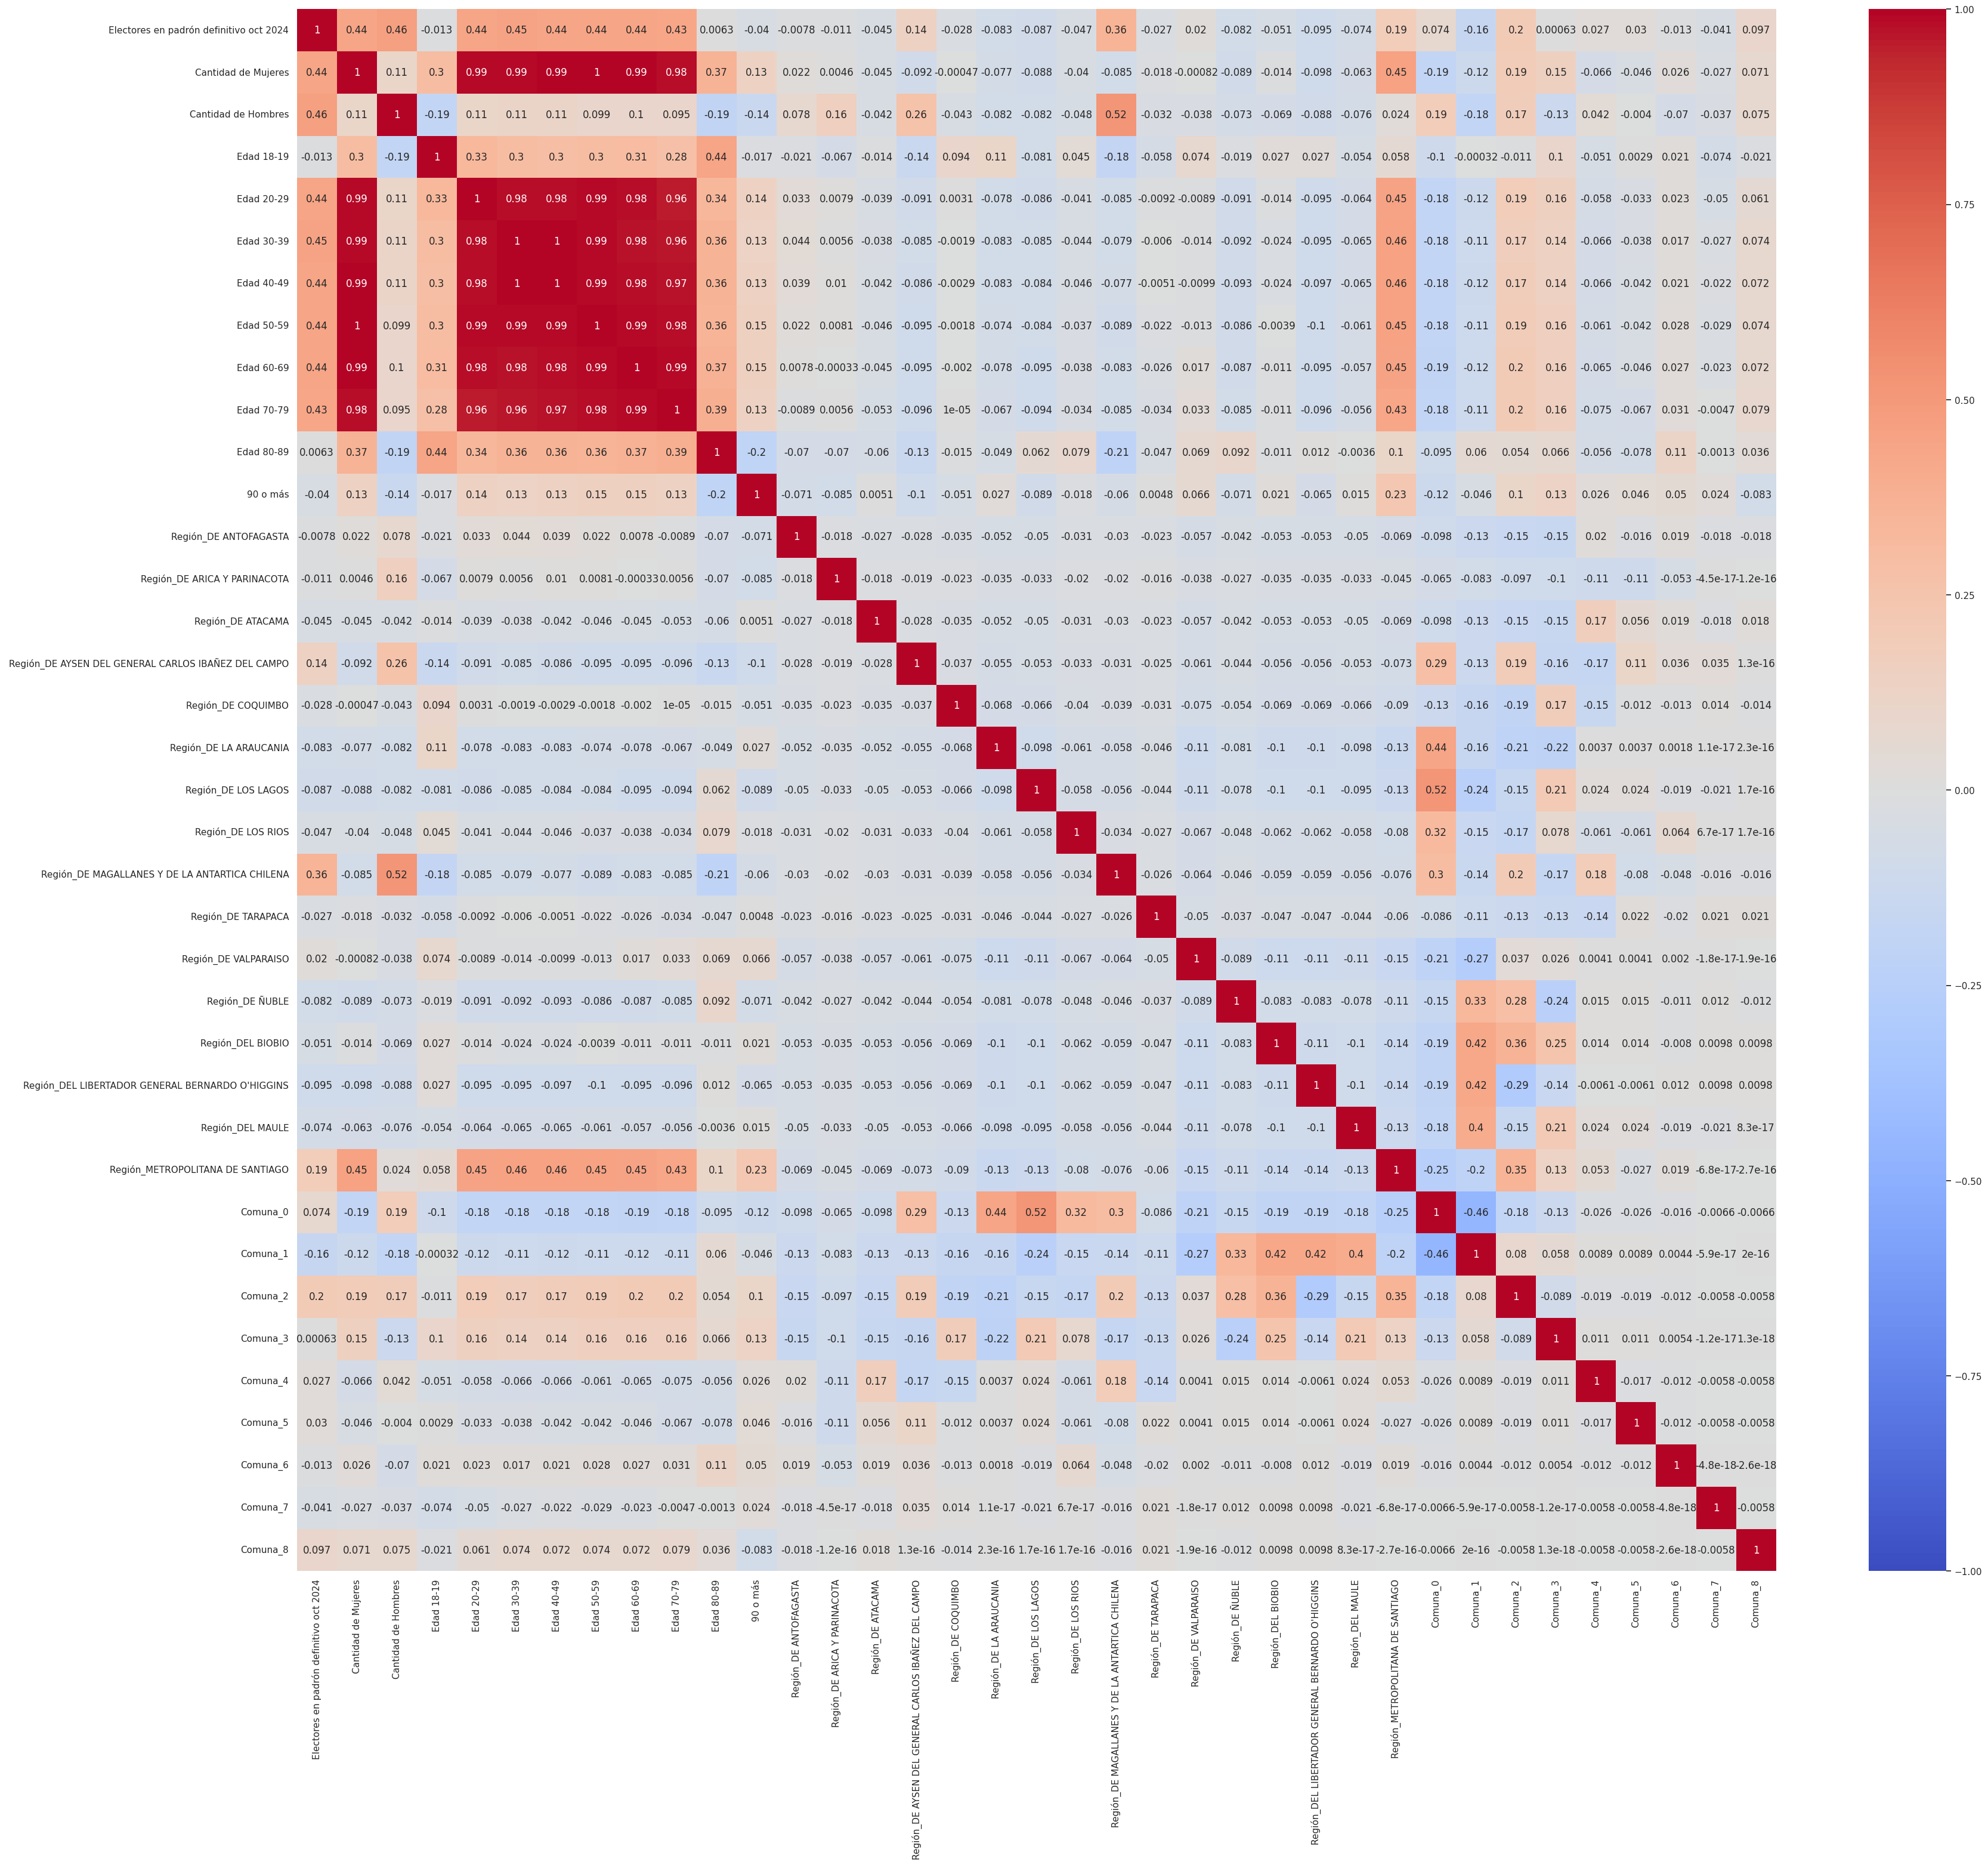

In [ ]:
corr_matrix = df_final_esc.corr()

plt.figure(figsize=(40, 34))

sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    cmap="coolwarm"
)

plt.show()